## PARAMETER ESTIMATION NOTEBOOK (Gravity Compensation)

In [278]:
# =========================================================================================================================== Import
import time
import os
import shutil

%matplotlib ipympl
from matplotlib import pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

from scipy.linalg import solve_continuous_lyapunov, block_diag

import numpy as np
from tqdm import tqdm

import pandas as pd

from scipy.signal import butter, filtfilt, savgol_filter
from scipy.linalg import block_diag

import sys
build_path = "./ahand_finger_generatedFiles_py/build"
if os.path.exists(build_path):
    sys.path.append(os.path.abspath(build_path))
else:
    print(f"Warning: path '{build_path}' does not exist.")

from thunder_ahand_finger_py import thunder_ahand_finger

MESH_DIR = './description/urdf/meshes/'
URDF_PATH = './description/urdf/allegro_hand_description_right_B.urdf'
XML_PATH = './description/urdf/allegro_hand_description_right_B.xml'
JOINT_NAMES = ['joint_4_0', 'joint_5_0', 'joint_6_0', 'joint_7_0']

np.random.seed(41)


# Dynamic Model

$ M(q)\ddot{q} + C(q, \dot{q})\dot{q} + G(q) + D \dot{q} + F\text{sign}(\dot{q}) = Y(q, \dot{q}, \ddot{q})\,\pi = \tau $

$ Y(q, \dot{q}, \ddot{q}) \in \mathbb{R}^{n \times 48} $

# Regressor parameters
$ \pi_r^i = \begin{bmatrix} m^i, m^i c^i_x, m^i c^i_x, m^i c^i_x,   J^i_{xx},J^i_{xy},J^i_{xz},J^i_{yy},J^i_{yz},J^i_{zz} \end{bmatrix}'$

$ \pi_d^i = \begin{bmatrix} D^i \end{bmatrix} $

$ \pi_s^i = \begin{bmatrix} F^i \end{bmatrix} $

$ \pi = \begin{bmatrix} \pi^{1'}_r, ..., \pi^{1'}_r | \pi_d^1, ..., \pi_d^n | \pi_s^1, ..., \pi_s^n \end{bmatrix}'$

$ \pi_r \in \mathbb{R}^{40 \times 1}, \pi_d \in \mathbb{R}^{4 \times 1}, \pi_f \in \mathbb{R}^{4 \times 1}$

Output()

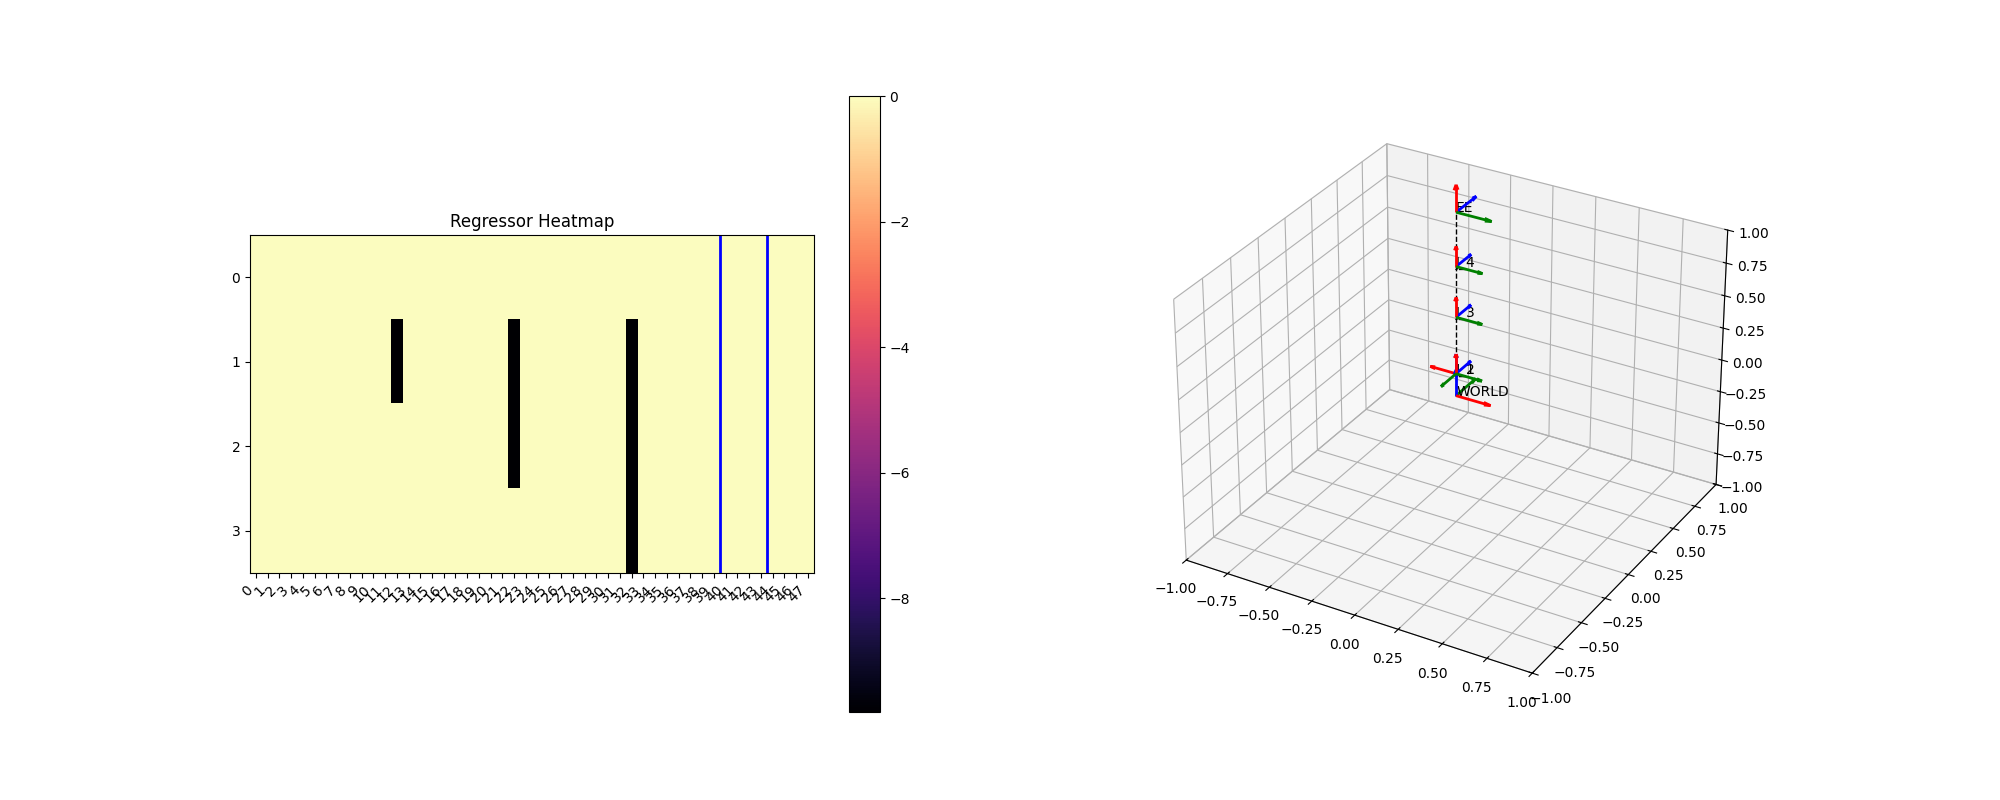

In [280]:
thunder_ahand = thunder_ahand_finger()
thunder_ahand.load_conf("/home/leo/thunder_dynamics/ahand_finger_generatedFiles/ahand_finger_conf.yaml")


# Sliders
q_sliders = [widgets.FloatSlider(value=0, min=-3.14, max=3.14, step=0.01, description=f'q{i}') for i in range(4)]
dq_sliders = [widgets.FloatSlider(value=0, min=-5, max=5, step=0.1, description=f'dq{i}') for i in range(4)]
ddq_sliders = [widgets.FloatSlider(value=0, min=-5, max=5, step=0.1, description=f'ddq{i}') for i in range(4)]

# Group sliders in boxes
q_box = widgets.VBox(q_sliders, layout=widgets.Layout(margin='0 0 10px 0'))
dq_box = widgets.VBox(dq_sliders, layout=widgets.Layout(margin='0 0 10px 0'))
ddq_box = widgets.VBox(ddq_sliders)

# Output widget
out = widgets.Output()


# Create figure and axes once
# --- Figure with two subplots: heatmap + 3D robot ---
fig = plt.figure(figsize=(20,8))
ax_heat = fig.add_subplot(1,2,1)
im = ax_heat.imshow(np.zeros((4,48)), cmap='magma', interpolation='nearest', aspect=0.6*12)
cbar = fig.colorbar(im, ax=ax_heat)
ax_heat.set_title('Regressor Heatmap')
ax_heat.set_xticks(np.arange(48))
ax_heat.set_yticks(np.arange(4))
plt.setp(ax_heat.get_xticklabels(), rotation=45, ha='right')
ax_heat.axvline(x=40-0.5, color='blue', linewidth=2)  # Damping regressor
ax_heat.axvline(x=44-0.5, color='blue', linewidth=2)  # Static regressor
# Annotate initial values
# texts = []
# for i in range(4):
#     row_texts = []
#     for j in range(48):
#         t = ax_heat.text(j, i, f"{0:.2f}", ha='center', va='center', color='black', fontsize=8)
#         row_texts.append(t)
#     texts.append(row_texts)

ax_3d = fig.add_subplot(1,2,2, projection='3d')
ax_3d.set_title('Robot Frames')


def plot_frame(T, ax, name=None, length=0.1):
    origin = T[:3, 3]
    x_axis = T[:3, 0] * length
    y_axis = T[:3, 1] * length
    z_axis = T[:3, 2] * length

    ax.quiver(*origin, *x_axis, color='r', linewidth=2, arrow_length_ratio=0.2)
    ax.quiver(*origin, *y_axis, color='g', linewidth=2, arrow_length_ratio=0.2)
    ax.quiver(*origin, *z_axis, color='b', linewidth=2, arrow_length_ratio=0.2)
    if name:
        ax.text(*origin, name, fontsize=10, color='k')


# Update function
def update(**kwargs):
    q = np.array([kwargs[f'q{i}'] for i in range(4)])
    dq = np.array([kwargs[f'dq{i}'] for i in range(4)])
    ddq = np.array([kwargs[f'ddq{i}'] for i in range(4)])

    thunder_ahand.set_q(q)
    thunder_ahand.set_dq(dq)
    thunder_ahand.set_dqr(dq)
    thunder_ahand.set_ddqr(ddq)
    # Compute regressor
    Y = thunder_ahand.get_reg_M() + thunder_ahand.get_reg_C() + thunder_ahand.get_reg_G()
    Y = thunder_ahand.get_Yr()
    Y_d = np.diag(dq)
    Y_s = np.diag(2/(1+np.exp(-20*dq)) - 1)
    Y = np.hstack([Y, Y_d, Y_s])
    # Compute transform
    frames = [np.eye(4)]  # Base frame
    for i in range(1, thunder_ahand.get_numJoints()+1):
        Ti = getattr(thunder_ahand, f"get_T_0_{i}")()  # Dynamically call robot.get_T_0_i()
        frames.append(Ti)
    frames.append(thunder_ahand.get_T_0_ee())  # End-Effecto frame

    # --- Update heatmap data ---
    im.set_data(Y)
    im.set_clim(vmin=Y.min(), vmax=Y.max())  # adjust color scale if needed
    # # Update annotations
    # for i in range(Y.shape[0]):
    #     for j in range(Y.shape[1]):
    #         texts[i][j].set_text(f"{Y[i,j]:.2f}")

    # --- Update 3D robot plot ---
    ax_3d.cla()  # Clear previous frames
    ax_3d.set_xlim(-1,1)
    ax_3d.set_ylim(-1,1)
    ax_3d.set_zlim(-1,1)
    for i, T in enumerate(frames):
        print(f"T_0_{i}:\n", T[:3, 3])
        if i == 0:
            plot_frame(T, ax_3d, 'WORLD', length=0.2)
        elif i == thunder_ahand.get_numJoints() + 1:
            plot_frame(T, ax_3d, 'EE', length=0.2)
        else:
            plot_frame(T, ax_3d, f'J_{i}', length=0.15)
    origins = np.array([T[:3, 3] for T in frames]) # Connect origins (optional, to show chain)
    ax_3d.plot(origins[:, 0], origins[:, 1], origins[:, 2], 'k--', linewidth=1)
    #for i, p in enumerate(origins):   # --- Add translation labels next to each point 
    #    label = f"({p[0]:.2f}, {p[1]:.2f}, {p[2]:.2f})"
    #    ax_3d.text(p[0], p[1], p[2] + 0.03, label, color='black', fontsize=9)
    
    fig.canvas.draw_idle()

# Combine sliders
all_sliders = {f'q{i}': s for i, s in enumerate(q_sliders)}
all_sliders.update({f'dq{i}': s for i, s in enumerate(dq_sliders)})
all_sliders.update({f'ddq{i}': s for i, s in enumerate(ddq_sliders)})

# Interactive widget
interactive_widget = widgets.interactive(update, **all_sliders)
display(widgets.HBox([q_box, dq_box, ddq_box]), out)

## Objective 
Regroup $\pi_r \rightarrow \hat{\pi}_r$  
s.t.  
$Y(q,\dot{q},\ddot{q})\pi_r = [Y_I(q,\dot{q},\ddot{q}) \;|\; Y_I(q,\dot{q},\ddot{q}) \beta ] \cdot \begin{bmatrix}
                                                                                                            \pi_{I,r} \\
                                                                                                            \pi_{D,r}
                                                                                                        \end{bmatrix}$  
$ \tau = Y_I(\pi_{I,r}+\beta\pi_{I,r}) = Y_I\hat{\pi}_{I,r}$ 


## Grouping inertial parameters by using Energy Model
Considering the $\textbf{Modified Denavit-Hartenberg convention}$ for representing a serial manipulator,  
Let be the inertial parameters vector of the i-th link:
$$ \pi_r^i = \begin{bmatrix} m^i, m^i c^i_x, m^i c^i_x, m^i c^i_x,   J^i_{xx},J^i_{xy},J^i_{xz},J^i_{yy},J^i_{yz},J^i_{zz} \end{bmatrix}'$$
  
Then:  
$$^{i-1}\Lambda_i \in \mathbb{R}^{10 \times 10}$$
s.t.  
$$h_i = h_{i-1}\cdot {}^{i-1}\Lambda_i + \dot{q}_i \nu_i$$
Where  
$$h_i: \text{Energy value due to i-th link linear in its dynamic parameters }(L_i = T_i + U_i = h_i \pi_r^i)$$
$$\nu_i = [to add]$$
<u>Oss 1</u> $^{i-1}\Lambda_i$ allows to remap the inertial parameters efffect in the previous frame  
<u>Oss 2</u> if $h_i $ is costant the effect of $\pi^i_r$ can be fully remapped on previus link  


Table belows is the explicit value of $^{i-1}\Lambda_i$
<table style="border-collapse: collapse; background-color: white; color:black">
  <tr>
    <th style="border: 1px solid black; padding: 4px;">m</td>
    <th style="border: 1px solid black; padding: 4px;">c<sub>x</sub></td>
    <th style="border: 1px solid black; padding: 4px;">c<sub>y</sub></td>
    <th style="border: 1px solid black; padding: 4px;">c<sub>z</sub></td>
    <th style="border: 1px solid black; padding: 4px;">I<sub>xx</sub></td>
    <th style="border: 1px solid black; padding: 4px;">I<sub>xy</sub></td>
    <th style="border: 1px solid black; padding: 4px;">I<sub>xz</sub></td>
    <th style="border: 1px solid black; padding: 4px;">I<sub>yy</sub></td>
    <th style="border: 1px solid black; padding: 4px;">I<sub>yz</sub></td>
    <th style="border: 1px solid black; padding: 4px;">I<sub>zz</sub></td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 4px;">1</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 4px;">a</td>
    <td style="border: 1px solid black; padding: 4px;">C<span style="color:blue">θ</span></td>
    <td style="border: 1px solid black; padding: 4px;">-S<span style="color:blue">θ</span></td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 4px;">-<span style="color:red">d</span>Sα</td>
    <td style="border: 1px solid black; padding: 4px;">S<span style="color:blue">θ</span>Cα</td>
    <td style="border: 1px solid black; padding: 4px;">C<span style="color:blue">θ</span>Cα</td>
    <td style="border: 1px solid black; padding: 4px;">-Sα</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 4px;"><span style="color:red">d</span>Cα</td>
    <td style="border: 1px solid black; padding: 4px;">S<span style="color:blue">θ</span>Sα</td>
    <td style="border: 1px solid black; padding: 4px;">C<span style="color:blue">θ</span>Sα</td>
    <td style="border: 1px solid black; padding: 4px;">Cα</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 4px;"><span style="color:red">d</span>²</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">2<span style="color:red">d</span></td>
    <td style="border: 1px solid black; padding: 4px;">C²<span style="color:blue">θ</span></td>
    <td style="border: 1px solid black; padding: 4px;">-2CS<span style="color:blue">θ</span></td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">S²<span style="color:blue">θ</span></td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 4px;">a<span style="color:red">d</span>Sα</td>
    <td style="border: 1px solid black; padding: 4px;">-aS<span style="color:blue">θ</span>Cα + <span style="color:red">d</span>C<span style="color:blue">θ</span>Sα</td>
    <td style="border: 1px solid black; padding: 4px;">-aC<span style="color:blue">θ</span>Cα + <span style="color:red">d</span>S<span style="color:blue">θ</span>Sα</td>
    <td style="border: 1px solid black; padding: 4px;">aSα</td>
    <td style="border: 1px solid black; padding: 4px;">CS<span style="color:blue">θ</span>Cα</td>
    <td style="border: 1px solid black; padding: 4px;">(C²<span style="color:blue">θ</span> - S²<span style="color:blue">θ</span>)Cα</td>
    <td style="border: 1px solid black; padding: 4px;">-C<span style="color:blue">θ</span>Sα</td>
    <td style="border: 1px solid black; padding: 4px;">-CS<span style="color:blue">θ</span>Cα</td>
    <td style="border: 1px solid black; padding: 4px;">S<span style="color:blue">θ</span>Sα</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 4px;">-a<span style="color:red">d</span>Cα</td>
    <td style="border: 1px solid black; padding: 4px;">-aS<span style="color:blue">θ</span>Sα - <span style="color:red">d</span>C<span style="color:blue">θ</span>Cα</td>
    <td style="border: 1px solid black; padding: 4px;">-aC<span style="color:blue">θ</span>Sα + <span style="color:red">d</span>S<span style="color:blue">θ</span>Cα</td>
    <td style="border: 1px solid black; padding: 4px;">-aCα</td>
    <td style="border: 1px solid black; padding: 4px;">CS<span style="color:blue">θ</span>Sα</td>
    <td style="border: 1px solid black; padding: 4px;">(C²<span style="color:blue">θ</span> - S²<span style="color:blue">θ</span>)Sα</td>
    <td style="border: 1px solid black; padding: 4px;">-C<span style="color:blue">θ</span>Sα</td>
    <td style="border: 1px solid black; padding: 4px;">-CS<span style="color:blue">θ</span>Sα</td>
    <td style="border: 1px solid black; padding: 4px;">-S<span style="color:blue">θ</span>Sα</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 4px;">a² + <span style="color:red">d</span>²C²α</td>
    <td style="border: 1px solid black; padding: 4px;">2(aC<span style="color:blue">θ</span> + <span style="color:red">d</span>S<span style="color:blue">θ</span>CSα)</td>
    <td style="border: 1px solid black; padding: 4px;">2(-aS<span style="color:blue">θ</span> + <span style="color:red">d</span>C<span style="color:blue">θ</span>CSα)</td>
    <td style="border: 1px solid black; padding: 4px;">2<span style="color:red">d</span>C²α</td>
    <td style="border: 1px solid black; padding: 4px;">S²<span style="color:blue">θ</span>C²α</td>
    <td style="border: 1px solid black; padding: 4px;">2CS<span style="color:blue">θ</span>C²α</td>
    <td style="border: 1px solid black; padding: 4px;">-2S<span style="color:blue">θ</span>CSα</td>
    <td style="border: 1px solid black; padding: 4px;">C²<span style="color:blue">θ</span>C²α</td>
    <td style="border: 1px solid black; padding: 4px;">-2C<span style="color:blue">θ</span>CSα</td>
    <td style="border: 1px solid black; padding: 4px;">s²<span style="color:blue">θ</span></td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 4px;"><span style="color:red">d</span>²CSα</td>
    <td style="border: 1px solid black; padding: 4px;"><span style="color:red">d</span>S<span style="color:blue">θ</span>(S²α-C²α)</td>
    <td style="border: 1px solid black; padding: 4px;"><span style="color:red">d</span>C<span style="color:blue">θ</span>(S²α-C²α)</td>
    <td style="border: 1px solid black; padding: 4px;">2<span style="color:red">d</span>CSα</td>
    <td style="border: 1px solid black; padding: 4px;">S²<span style="color:blue">θ</span>CSα</td>
    <td style="border: 1px solid black; padding: 4px;">2CS<span style="color:blue">θ</span>CSα</td>
    <td style="border: 1px solid black; padding: 4px;">S<span style="color:blue">θ</span>(C²α-s²α)</td>
    <td style="border: 1px solid black; padding: 4px;">C²<span style="color:blue">θ</span>CSα</td>
    <td style="border: 1px solid black; padding: 4px;">c<span style="color:blue">θ</span>(C²α-s²α)</td>
    <td style="border: 1px solid black; padding: 4px;">-CSα</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 4px;">a² + <span style="color:red">d</span>²S²α</td>
    <td style="border: 1px solid black; padding: 4px;">2(aC<span style="color:blue">θ</span> - <span style="color:red">d</span>S<span style="color:blue">θ</span>CSα)</td>
    <td style="border: 1px solid black; padding: 4px;">2(-aS<span style="color:blue">θ</span> - <span style="color:red">d</span>C<span style="color:blue">θ</span>CSα)</td>
    <td style="border: 1px solid black; padding: 4px;">2<span style="color:red">d</span>S²α</td>
    <td style="border: 1px solid black; padding: 4px;">S²<span style="color:blue">θ</span>S²α</td>
    <td style="border: 1px solid black; padding: 4px;">2CS<span style="color:blue">θ</span>S²α</td>
    <td style="border: 1px solid black; padding: 4px;">2S<span style="color:blue">θ</span>CSα</td>
    <td style="border: 1px solid black; padding: 4px;">C²<span style="color:blue">θ</span>S²α</td>
    <td style="border: 1px solid black; padding: 4px;">2c<span style="color:blue">θ</span>Csα</td>
    <td style="border: 1px solid black; padding: 4px;">C²α</td>
  </tr>
</table>

Note:  
- If i-th joint ${\color{red}prismatic}$ then ${\color{red}d}$ is the joint variable  
- If i-th joint ${\color{blue}revolute}$ then ${\color{blue}\theta}$ is the joint variable

In [286]:
def Lambda(alpha, a, d, theta):
    sa = np.sin(alpha)
    ca = np.cos(alpha)
    st = np.sin(theta)
    ct = np.cos(theta)

    ssa = np.sin(alpha)*np.sin(alpha)
    cca = np.cos(alpha)*np.cos(alpha)
    sst = np.sin(theta)*np.sin(theta)
    cct = np.cos(theta)*np.cos(theta)

    csa = np.cos(alpha)*np.sin(alpha)
    cst = np.cos(theta)*np.sin(theta)

    L = np.zeros((10,10))

    # Mass
    L[:,0] = np.array([1,   a,-d*sa,d*ca,   d**2, a*d*sa, -a*d*ca, a**2 + d**2*cca, d**2*csa, a**2 + d**2*ssa])
    # m*COM
    L[:,1] = np.array([0,   ct, st*ca, st*sa,   0, -a*st*ca + d*ct*sa, -a*st*sa - d*ct*ca, 2*(a*ct + d*st*csa), d*st*(ssa-cca), 2*(a*ct - d*st*csa)])
    L[:,1] = np.array([0,   -st, ct*ca, ct*sa,  0, -a*ct*ca + d*st*sa, -a*ct*sa - d*st*ca, 2*(-a*st + d*ct*csa), d*ct*(ssa-cca), 2*(-a*st - d*ct*csa)])
    L[:,3] = np.array([0,   0, -sa, ca,         2*d, a*sa, -a*ca, 2*d*cca, 2*d*csa, 2*d*ssa])
    # Inertia
    L[:,4] = np.array([0,   0, 0, 0,  cct, cst*ca, cst*sa, sst*cca, sst*csa, sst*ssa])
    L[:,5] = np.array([0,   0, 0, 0,  -2*cst, (cct -sst)*ca, (cct -sst)*sa, 2*cst*cca, 2*cst*csa, 2*cst*ssa])
    L[:,6] = np.array([0,   0, 0, 0,  0, -ct*sa, -ct*sa, -2*st*csa, st*(cca-ssa), 2*st*csa])
    L[:,7] = np.array([0,   0, 0, 0,  sst, -cst*ca, -cst*sa, cct*cca, cct*csa, cct*ssa])
    L[:,8] = np.array([0,   0, 0, 0,  0, st*sa, -st*sa, -2*ct*csa, ct*(cca-ssa), 2*ct*csa])
    L[:,9] = np.array([0,   0, 0, 0,  0, 0, 0, sst, -csa, cca])

    return L


def S(k, n):
    # selettore parametri k s.t. pi_r_k = S_k * pi_r
    S = np.zeros((10, n*10))
    S[:, k*10:(k+1)*10] = np.eye(10)
    return S

In [287]:
# Denavit-Hartenberg parameters
DH = { 'joints':[0,         0,      0,      0], # 0: revolute, 1: prismatic
       'a':     [0,         0,      0.431,  0.38],
       'alpha': [0,        np.pi/2,  0,      0],
       'd':     [0.17,      0,      0,      0],
       'theta': [np.pi,   np.pi/2,  0,      0]}
i = 0
iminus_L_i = Lambda(DH['alpha'][i], DH['a'][i], DH['d'][i], DH['theta'][i])
#                           m,                               cx,cy,        cz,                             I_xx,I_xy,I_xz,               I_yy,                            I_yz,I_zz,    |     pi_r
H_iminus = np.hstack([iminus_L_i[:,0].reshape(-1, 1),  np.zeros((10,2)),iminus_L_i[:,3].reshape(-1, 1),  np.zeros((10,3)),(iminus_L_i[:,4] + iminus_L_i[:,7]).reshape(-1, 1),np.zeros((10,2)), np.eye(10)])
print(np.array2string(H_iminus[:,0:10], 
                      precision=3,      # number of decimals
                      floatmode='fixed',
                      suppress_small=True))

[[ 1.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000]
 [ 0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000]
 [-0.000  0.000  0.000 -0.000  0.000  0.000  0.000  0.000  0.000  0.000]
 [ 0.170  0.000  0.000  1.000  0.000  0.000  0.000  0.000  0.000  0.000]
 [ 0.029  0.000  0.000  0.340  0.000  0.000  0.000  1.000  0.000  0.000]
 [ 0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000]
 [ 0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000]
 [ 0.029  0.000  0.000  0.340  0.000  0.000  0.000  1.000  0.000  0.000]
 [ 0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000]
 [ 0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000]]


In [292]:

# PI: &1 3.14163267948966
# PI_2: &2 1.5707963267948966
# PI_2_neg: -1.5707963267948966
# num_joints: 4
# type_joints: [R, R, R, R]
# kinematics:
#   symb: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
#   DH: [0,     0,      0.17,   *1,
#        0,     *2,     0,      *2,
#        0.431, 0,      0,       0,
#        0.38,  0,      0,       0]
# Denavit-Hartenberg parameters
DH = { 'joints':['R',      'R',     'R',    'R'], # 0: revolute, 1: prismatic

       'a':     [0,         0,      0.431,  0.38],
       'alpha': [0,       np.pi/2,  0,      0],
       'd':     [0.17,      0,      0,      0],
       'theta': [np.pi,   np.pi/2,  0,      0]}

def regrouping(DH):
    # get r1 and r2 # TO DO
    r1 = 1
    r2 = 2

    n = len(DH['joints'])
    pi_r = np.ones((n*10,1))       # original parameter vector
    hat_pi_r =[]

    E = []
    H = []
    W = []
    for i in range(n-1, -1, -1):
        #  ----------- revolute ----------------------------
        if DH['joints'][i] == 'R':
            # 1) Get i-th param
            S_i = S(i, n)                   # param selector
            pi_r_i = S_i @ pi_r             # pi_r_i = [m, cx,cy,cz, I_xx,I_xy,I_xz,I_yy,I_yz,I_zz]

            # 2) Get type of param reduction (compute E_i)
            E_i = block_diag(1,
                               np.eye(3),
                                        np.array([[1,0,0,-1,0,0],         # regroup I_yy in I_xx
                                                  [0,1,0, 0,0,0],
                                                  [0,0,1, 0,0,0],
                                                  [0,0,0, 1,0,0],
                                                  [0,0,0, 0,1,0],
                                                  [0,0,0, 0,0,1]]))
            print(f"Deleting I_yy, mc_z, m of link {i}...")
            E_i = E_i[[ 1,2, 4,5,6,8,9],:]                                      # Remove m, cz, I_yy
            if i+1<r2 and i+1>=r1:
                print(f"Deleting I_xx, I_xy, I_xz, I_yz of link {i}...")
                E_i = E_i[[ 0,1, 6],:]                                          # remove I_xx, I_xy, I_xz, I_yz
                if False:
                    print(f"Deleting mc_x, mc_y of link {i}...")
                    E_i = E_i[[ 2],:]                                               # remove mc_x, mc_y (TO DO)



            # 3) Remapping on previous (compute H_iminus)
            if i>0:
                iminus_L_i = Lambda(DH['alpha'][i], DH['a'][i], DH['d'][i], DH['theta'][i])
                #                           m,                               cx,cy,        cz,                             I_xx,I_xy,I_xz,               I_yy,                            I_yz,I_zz,    |     pi_r
                H_iminus = np.hstack([iminus_L_i[:,0].reshape(-1, 1),  np.zeros((10,2)),iminus_L_i[:,3].reshape(-1, 1),  np.zeros((10,3)),(iminus_L_i[:,4] + iminus_L_i[:,7]).reshape(-1, 1),np.zeros((10,2)), np.eye(10)])

                hat_pi_i = E_i @ pi_r_i.reshape(-1, 1)
                pi_r[10*(i-1):10*i,:] = H_iminus @ np.vstack([pi_r_i,pi_r[10*(i-1):10*i,:]])

            else:  # base link
                hat_pi_i = E_i @ pi_r_i.reshape(-1, 1)

            # 4) Get relationship parameters-reduced parameter i-th (Compute of W_i)
            if i==n-1:
                W_i = S_i
                H_i = np.eye(10)
                H = [H_i] + H
            else:
                H_i = H[0]
                H_iplus = H[1]
                W_iplus = W[0]
                W_i = np.vstack([H_iplus @ W_iplus,
                                 S_i])
            if i>0:  H = [H_iminus] + H
            W = [W_i] + W
            E = [E_i] + E


            hat_pi_r = hat_pi_i.flatten().tolist() + hat_pi_r
    print(f"Regrouping completed. From {len(pi_r.tolist())} to a reduced parameter vector of length:", len(hat_pi_r))

    beta = []
    for i in range(n):
        beta.append(E[i] @ H[i] @ W[i])
    beta = np.vstack(beta)

    return hat_pi_r, beta

In [294]:
_,beta =regrouping(DH)

thunder_ahand = thunder_ahand_finger()
thunder_ahand.load_conf("/home/leo/thunder_dynamics/ahand_finger_generatedFiles/ahand_finger_conf.yaml")

pi = 100*np.random.rand(40,1)
print(f"Params: {pi.transpose()}")
pi_reduced = beta @ pi

# Sliders
q_sliders = [widgets.FloatSlider(value=0, min=-3.14, max=3.14, step=0.01, description=f'q{i}') for i in range(4)]
dq_sliders = [widgets.FloatSlider(value=0, min=-5, max=5, step=0.1, description=f'dq{i}') for i in range(4)]
ddq_sliders = [widgets.FloatSlider(value=0, min=-5, max=5, step=0.1, description=f'ddq{i}') for i in range(4)]

# Group sliders in boxes
q_box = widgets.VBox(q_sliders, layout=widgets.Layout(margin='0 0 10px 0'))
dq_box = widgets.VBox(dq_sliders, layout=widgets.Layout(margin='0 0 10px 0'))
ddq_box = widgets.VBox(ddq_sliders)

# Output widget
out = widgets.Output()


# Update function
def update(**kwargs):
    q = np.array([kwargs[f'q{i}'] for i in range(4)])
    dq = np.array([kwargs[f'dq{i}'] for i in range(4)])
    ddq = np.array([kwargs[f'ddq{i}'] for i in range(4)])

    thunder_ahand.set_q(q)
    thunder_ahand.set_dq(dq)
    thunder_ahand.set_dqr(dq)
    thunder_ahand.set_ddqr(ddq)
    # Compute regressor
    Y = thunder_ahand.get_Yr()
    Y_hat = Y @ np.linalg.pinv(beta)

    with out:
        out.clear_output(wait=True)
        print("Tau Error: " + np.array2string((Y@pi - Y_hat @ pi_reduced).transpose(), 
                      precision=3,      # number of decimals
                      floatmode='fixed',
                      suppress_small=True))

# Combine sliders
all_sliders = {f'q{i}': s for i, s in enumerate(q_sliders)}
all_sliders.update({f'dq{i}': s for i, s in enumerate(dq_sliders)})
all_sliders.update({f'ddq{i}': s for i, s in enumerate(ddq_sliders)})

# Interactive widget
interactive_out = widgets.interactive_output(update, all_sliders)
display(widgets.VBox([
    widgets.HBox([q_box, dq_box, ddq_box]),
    out,
    interactive_out
]))

Deleting I_yy, mc_z, m of link 3...
Deleting I_yy, mc_z, m of link 2...
Deleting I_yy, mc_z, m of link 1...
Deleting I_yy, mc_z, m of link 0...
Deleting I_xx, I_xy, I_xz, I_yz of link 0...
Regrouping completed. From 40 to a reduced parameter vector of length: 24
Params: [[98.31195842  9.45597107 40.88889226 13.2923275   4.44370673 70.90791382
  85.68861368 77.36435921 76.12181853 67.08646758  9.20117118 62.96020437
  94.41751458 11.07443165 14.97794648 60.06289188  1.45985006 56.01666077
   3.21620587 25.06928782 28.9984523   5.85299847 36.41413001 42.78746112
  23.15712751 96.77504654 74.02960356 44.37651722 49.78441551 21.58896081
  72.1993795  84.12001259  3.12837026 62.5484168  89.10895838 18.42159147
   7.2467618  89.04856842 52.83135513 60.95198046]]
